In [48]:
from scipy.io import loadmat
import numpy as np
from sklearn.model_selection import KFold   
import matplotlib.pyplot as plt

In [53]:
data = loadmat(r'data/data.mat')['data']
X = data[:,0]
y= data[:,1]

In [17]:
ones = np.ones(len(X))

In [56]:
def kernel_function(x,xi,h):
                                                                                           
    return (1 / (np.sqrt(2 * np.pi) * h)) * np.exp(-np.linalg.norm(x - xi)**2 / (2 * h**2))


def regression(x_q,x,y_t,h):
    n= len(x)
    W = np.diag([kernel_function(x_q,x[i],h) for i in range(n)])
    x_r = np.column_stack([np.ones(n),x-x_q])
    x_w = x_r.T@W
    b, _, _, _ = np.linalg.lstsq(x_w @ x_r, x_w @ y_t, rcond=None)
    return b[0]



4.2

In [ ]:
h_s = np.logspace(-1, 1, 100)
folds = KFold(n_splits=5,shuffle=False)
folds
errors = []

for h in h_s:
    f_error = []
    for train_index,test_index in folds.split(X):
        x_train,x_test = X[train_index],X[test_index]
   
        y_train,y_test = y[train_index], y[test_index]
        predictions = [regression(x,x_train,y_train,h) for x in x_test]
        mse = np.mean((np.array(predictions)-y_test)**2)
        f_error.append(mse)

    errors.append(np.mean(f_error))




[-2.36 -2.32 -2.28 -2.24 -2.2  -2.16 -2.12 -2.08 -2.04 -2.   -1.96 -1.92
 -1.88 -1.84 -1.8  -1.76 -1.72 -1.68 -1.64 -1.6  -1.56 -1.52 -1.48 -1.44
 -1.4  -1.36 -1.32 -1.28 -1.24 -1.2  -1.16 -1.12 -1.08 -1.04 -1.   -0.96
 -0.92 -0.88 -0.84 -0.8  -0.76 -0.72 -0.68 -0.64 -0.6  -0.56 -0.52 -0.48
 -0.44 -0.4  -0.36 -0.32 -0.28 -0.24 -0.2  -0.16 -0.12 -0.08 -0.04  0.
  0.04  0.08  0.12  0.16  0.2   0.24  0.28  0.32  0.36  0.4   0.44  0.48
  0.52  0.56  0.6   0.64  0.68  0.72  0.76  0.8   0.84  0.88  0.92  0.96
  1.    1.04  1.08  1.12  1.16  1.2   1.24  1.28  1.32  1.36  1.4   1.44
  1.48  1.52  1.56  1.6   1.64  1.68  1.72  1.76  1.8   1.84  1.88  1.92
  1.96  2.    2.04  2.08  2.12  2.16  2.2   2.24  2.28  2.32  2.36  2.4
  2.44  2.48  2.52  2.56  2.6   2.64  2.68  2.72  2.76  2.8   2.84  2.88
  2.92  2.96  3.    3.04  3.08  3.12  3.16  3.2   3.24  3.28  3.32  3.36
  3.4   3.44  3.48  3.52  3.56  3.6   3.64  3.68  3.72  3.76  3.8   3.84
  3.88  3.92  3.96  4.  ]
[-4.   -3.96 -3.92 -3.88 -3.

In [79]:
[np.argmin(errors)]
errors[32]

np.float64(0.1840577921950492)

Optimal h: 0.4430621457583881


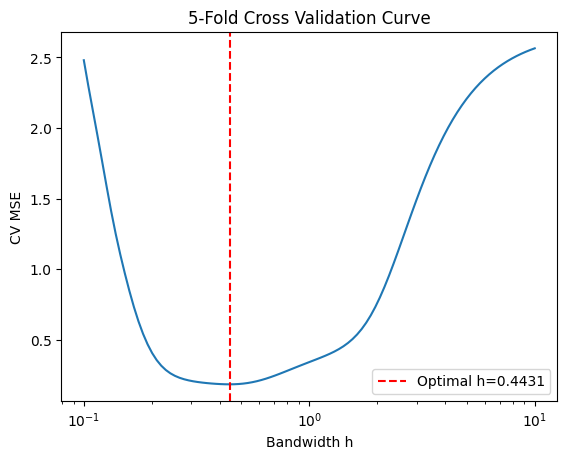

In [ ]:
best_h = h_s[np.argmin(errors)]
print(f"Optimal h: {best_h}")

plt.plot(h_s, errors)
plt.xscale('log')
plt.xlabel('Bandwidth h')
plt.ylabel('CV MSE')
plt.title('5-Fold Cross Validation Curve')
plt.axvline(best_h, color='r', linestyle='--', label=f'Optimal h={best_h:.4f}')
plt.legend()
plt.show()

4.3

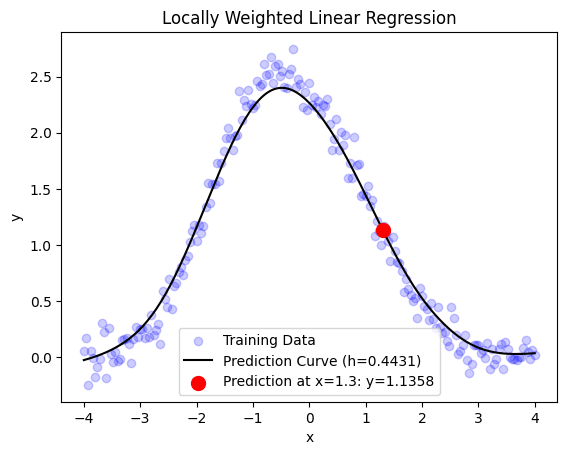

In [76]:
prediction_13 = regression(1.3,X,y,best_h)

range_x = np.linspace(X.min(),X.max(),200)

curve = [regression(x, X, y, best_h) for x in range_x]    

plt.scatter(X, y, color='blue', alpha=0.2, label='Training Data')
plt.plot(range_x, curve, color='black', label=f'Prediction Curve (h={best_h:.4f})')                   
plt.scatter(1.3, prediction_13, color='red', zorder=5, s=100, label=f'Prediction at x=1.3: y={prediction_13:.4f}')     
plt.xlabel('x')                                                                                            
plt.ylabel('y')                                                                                            
plt.title('Locally Weighted Linear Regression')                                                            
plt.legend()    
plt.show()
